## Random Forest Classification Model(many randomized decision trees combined)

Building and evaluating a scikit-learn Random Forest Classifier to predict passenger satisfaction.

### Workflow

**Prepared Data**  
↓  
**Random Forest Classifier**  
↓  
**5-Fold Cross-Validation**  
↓  
**Initial Model Evaluation**  
↓  
**Hyperparameter Tuning**  
↓  
**Tuned Model Evaluation**  
↓  
**Initial vs. Tuned Comparison**  
↓  
**Final Test Evaluation**  
↓  
**Feature Importance**

In [1]:
# Import the libraries needed for Random Forest classification and evaluation

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    make_scorer
)

### Load prepared data

In [2]:
# Load the prepared training and test datasets created in the preprocessing notebook
train = pd.read_csv("../prepared_data/train_prepared.csv")
test = pd.read_csv("../prepared_data/test_prepared.csv")

print("Training:", train.shape)
print("Test:", test.shape)

Training: (103594, 23)
Test: (25893, 23)


### Prepare Predictors and Target

In [3]:
# Separate the input features (X) from the target variable (y)
# The training data will be used for model development, while the test data is kept for final evaluation

X_train = train.drop(columns=["satisfaction"])
y_train = train["satisfaction"]

X_test = test.drop(columns=["satisfaction"])
y_test = test["satisfaction"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (103594, 22)
y_train: (103594,)
X_test: (25893, 22)
y_test: (25893,)


### Identify and Encode Categorical Variables

In [4]:
# First identify all categorical columns in the training features

categorical_columns = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [5]:
# Convert categorical columns to numbers and keep the other columns unchanged

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

preprocessor

,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [6]:
# Convert the two satisfaction categories to 0 and 1 for model evaluation

target_mapping = {
    "neutral or dissatisfied": 0,
    "satisfied": 1
}

y_train = y_train.map(target_mapping)
y_test = y_test.map(target_mapping)

print("Target values:", sorted(y_train.unique()))
print("\nTraining target counts:")
print(y_train.value_counts())

Target values: [np.int64(0), np.int64(1)]

Training target counts:
satisfaction
0    58697
1    44897
Name: count, dtype: int64


### Create the Random Forest Model

In [7]:
# Create one model that first prepares the data, then trains a Random Forest using many decision trees

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 5-Fold Cross-Validation

In [8]:
# Split the training data into 5 folds for repeated training and validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [9]:
# Define the metrics used to evaluate the Random Forest during cross-validation

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "sensitivity": "recall",
    "specificity": make_scorer(recall_score, pos_label=0),
    "roc_auc": "roc_auc"
}

print("Metrics:", list(scoring.keys()))

Metrics: ['accuracy', 'precision', 'sensitivity', 'specificity', 'roc_auc']


In [10]:
# Run 5-fold cross-validation and calculate the selected metrics for each fold

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

cv_results

{'fit_time': array([1.46315074, 1.58675003, 1.39098859, 1.58555698, 1.23788738]),
 'score_time': array([0.13676739, 0.14991522, 0.12928891, 0.13373852, 0.11846638]),
 'test_accuracy': array([0.96370481, 0.96119504, 0.96249819, 0.96365655, 0.96379959]),
 'test_precision': array([0.97297919, 0.97063903, 0.97454588, 0.97221903, 0.97200872]),
 'test_sensitivity': array([0.94242121, 0.93885733, 0.93797327, 0.94309577, 0.94364629]),
 'test_specificity': array([0.97998296, 0.97827939, 0.98125905, 0.97938496, 0.97921458]),
 'test_roc_auc': array([0.99460057, 0.99382632, 0.99390217, 0.99412219, 0.99395844])}

In [11]:
# Organize the 5-fold results into a clear table and calculate the mean and standard deviation

cv_table = pd.DataFrame({
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Sensitivity": cv_results["test_sensitivity"],
    "Specificity": cv_results["test_specificity"],
    "ROC-AUC": cv_results["test_roc_auc"]
})

cv_table.index = [f"Fold {i}" for i in range(1, 6)]

cv_table.loc["Mean"] = cv_table.mean()
cv_table.loc["Std"] = cv_table.iloc[:5].std()

print(cv_table.round(4))

        Accuracy  Precision  Sensitivity  Specificity  ROC-AUC
Fold 1    0.9637     0.9730       0.9424       0.9800   0.9946
Fold 2    0.9612     0.9706       0.9389       0.9783   0.9938
Fold 3    0.9625     0.9745       0.9380       0.9813   0.9939
Fold 4    0.9637     0.9722       0.9431       0.9794   0.9941
Fold 5    0.9638     0.9720       0.9436       0.9792   0.9940
Mean      0.9630     0.9725       0.9412       0.9796   0.9941
Std       0.0011     0.0014       0.0026       0.0011   0.0003


### Initial Random Forest Evaluation

In [12]:
# Save the initial Random Forest cross-validation results for later reporting and comparison

checkpoint_dir = Path("../checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

with open(checkpoint_dir / "06_random_forest_initial_cv.txt", "w") as f:
    f.write("INITIAL RANDOM FOREST - 5-FOLD CROSS-VALIDATION\n\n")
    f.write(cv_table.to_string(index=False))
    f.write("\n\nMean Results:\n")
    f.write(cv_table.mean(numeric_only=True).to_string())
    f.write("\n\nStandard Deviation:\n")
    f.write(cv_table.std(numeric_only=True).to_string())

print("Saved: 06_random_forest_initial_cv.txt")

Saved: 06_random_forest_initial_cv.txt


#### Check for Overfitting

In [13]:
# Compare training and validation accuracy to check whether the initial Random Forest is overfitting

overfitting_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1
)

mean_train_accuracy = overfitting_results["train_score"].mean()
mean_validation_accuracy = overfitting_results["test_score"].mean()
accuracy_gap = mean_train_accuracy - mean_validation_accuracy

print(f"Mean training accuracy:   {mean_train_accuracy:.4f}")
print(f"Mean validation accuracy: {mean_validation_accuracy:.4f}")
print(f"Difference:               {accuracy_gap:.4f}")

Mean training accuracy:   1.0000
Mean validation accuracy: 0.9630
Difference:               0.0370


In [14]:
# Save the initial Random Forest overfitting check for later reporting and comparison

with open(checkpoint_dir / "07_random_forest_overfitting.txt", "w") as f:
    f.write("INITIAL RANDOM FOREST - OVERFITTING CHECK\n\n")
    f.write(f"Mean training accuracy:   {mean_train_accuracy:.4f}\n")
    f.write(f"Mean validation accuracy: {mean_validation_accuracy:.4f}\n")
    f.write(f"Difference:               {accuracy_gap:.4f}\n")

print("Saved: 07_random_forest_overfitting.txt")

Saved: 07_random_forest_overfitting.txt


### Hyperparameter Tuning

In [15]:
# Define a small parameter grid to find a better Random Forest without making the search unnecessarily expensive

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 20],
    "classifier__min_samples_split": [2, 10],
    "classifier__min_samples_leaf": [1, 5]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print(f"\nBest validation accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

Best validation accuracy: 0.9630


### Tuned Random Forest Evaluation

In [16]:
# Evaluate the tuned Random Forest using the same 5-fold cross-validation and metrics

tuned_model = grid_search.best_estimator_

tuned_cv_results = cross_validate(
    tuned_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

tuned_cv_table = pd.DataFrame({
    "Accuracy": tuned_cv_results["test_accuracy"],
    "Precision": tuned_cv_results["test_precision"],
    "Sensitivity": tuned_cv_results["test_sensitivity"],
    "Specificity": tuned_cv_results["test_specificity"],
    "ROC-AUC": tuned_cv_results["test_roc_auc"]
})

tuned_cv_table.index = [f"Fold {i}" for i in range(1, 6)]

tuned_cv_table.loc["Mean"] = tuned_cv_table.mean()
tuned_cv_table.loc["Std"] = tuned_cv_table.iloc[:5].std()

print(tuned_cv_table.round(4))

print(f"\nMean training accuracy:   {tuned_cv_results['train_accuracy'].mean():.4f}")
print(f"Mean validation accuracy: {tuned_cv_results['test_accuracy'].mean():.4f}")

        Accuracy  Precision  Sensitivity  Specificity  ROC-AUC
Fold 1    0.9635     0.9723       0.9425       0.9795   0.9947
Fold 2    0.9608     0.9702       0.9383       0.9779   0.9939
Fold 3    0.9628     0.9736       0.9398       0.9805   0.9939
Fold 4    0.9640     0.9708       0.9454       0.9783   0.9941
Fold 5    0.9641     0.9725       0.9440       0.9796   0.9941
Mean      0.9630     0.9719       0.9420       0.9791   0.9941
Std       0.0014     0.0014       0.0029       0.0010   0.0003

Mean training accuracy:   0.9853
Mean validation accuracy: 0.9630


In [17]:
# Save the tuned Random Forest cross-validation results for later reporting and comparison

with open(checkpoint_dir / "08_random_forest_tuned_cv.txt", "w") as f:
    f.write("TUNED RANDOM FOREST - 5-FOLD CROSS-VALIDATION\n\n")
    f.write("Best parameters:\n")
    f.write(str(grid_search.best_params_))
    f.write("\n\nFold Results:\n")
    f.write(tuned_cv_table.to_string())
    f.write("\n\nMean Results:\n")
    f.write(tuned_cv_table.mean().to_string())
    f.write("\n\nStandard Deviation:\n")
    f.write(tuned_cv_table.std().to_string())
    f.write(f"\n\nMean training accuracy: {tuned_cv_results['train_accuracy'].mean():.4f}")
    f.write(f"\nMean validation accuracy: {tuned_cv_results['test_accuracy'].mean():.4f}")

print("Saved: 08_random_forest_tuned_cv.txt")

Saved: 08_random_forest_tuned_cv.txt


### Initial vs. Tuned Random Forest

In [18]:
# Compare the initial and tuned Random Forest models using their mean cross-validation results

comparison = pd.DataFrame({
    "Initial": [
        cv_table.loc["Mean", "Accuracy"],
        cv_table.loc["Mean", "Precision"],
        cv_table.loc["Mean", "Sensitivity"],
        cv_table.loc["Mean", "Specificity"],
        cv_table.loc["Mean", "ROC-AUC"],
        overfitting_results["train_score"].mean()
    ],
    "Tuned": [
        tuned_cv_table.loc["Mean", "Accuracy"],
        tuned_cv_table.loc["Mean", "Precision"],
        tuned_cv_table.loc["Mean", "Sensitivity"],
        tuned_cv_table.loc["Mean", "Specificity"],
        tuned_cv_table.loc["Mean", "ROC-AUC"],
        tuned_cv_results["train_accuracy"].mean()
    ]
}, index=[
    "Validation Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "ROC-AUC",
    "Training Accuracy"
])

comparison["Difference"] = comparison["Tuned"] - comparison["Initial"]

print(comparison.round(4))

                     Initial   Tuned  Difference
Validation Accuracy   0.9630  0.9630      0.0001
Precision             0.9725  0.9719     -0.0006
Sensitivity           0.9412  0.9420      0.0008
Specificity           0.9796  0.9791     -0.0005
ROC-AUC               0.9941  0.9941      0.0000
Training Accuracy     1.0000  0.9853     -0.0147


In [19]:
# Save the comparison between the initial and tuned Random Forest models

with open(checkpoint_dir / "09_random_forest_comparison.txt", "w") as f:
    f.write("INITIAL VS TUNED RANDOM FOREST\n\n")
    f.write(comparison.to_string())

print("Saved: 09_random_forest_comparison.txt")

Saved: 09_random_forest_comparison.txt


### Final Test Evaluation

In [20]:
# Train the tuned Random Forest on all training data and evaluate it once on the final test set

tuned_model.fit(X_train, y_train)

y_pred = tuned_model.predict(X_test)
y_prob = tuned_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_sensitivity = recall_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
test_specificity = tn / (tn + fp)

test_roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:    {test_accuracy:.4f}")
print(f"Precision:   {test_precision:.4f}")
print(f"Sensitivity: {test_sensitivity:.4f}")
print(f"Specificity: {test_specificity:.4f}")
print(f"ROC-AUC:     {test_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:    0.9631
Precision:   0.9711
Sensitivity: 0.9440
Specificity: 0.9780
ROC-AUC:     0.9941

Confusion Matrix:
[[14209   319]
 [  637 10728]]


In [21]:
# Save the final Random Forest test results and confusion matrix

with open(checkpoint_dir / "10_random_forest_final_test.txt", "w") as f:
    f.write("TUNED RANDOM FOREST - FINAL TEST EVALUATION\n\n")
    f.write(f"Accuracy:    {test_accuracy:.4f}\n")
    f.write(f"Precision:   {test_precision:.4f}\n")
    f.write(f"Sensitivity: {test_sensitivity:.4f}\n")
    f.write(f"Specificity: {test_specificity:.4f}\n")
    f.write(f"ROC-AUC:     {test_roc_auc:.4f}\n")
    f.write("\nConfusion Matrix:\n")
    f.write(f"TN: {tn}\n")
    f.write(f"FP: {fp}\n")
    f.write(f"FN: {fn}\n")
    f.write(f"TP: {tp}\n")

print("Saved: 10_random_forest_final_test.txt")

Saved: 10_random_forest_final_test.txt


### Feature Importance

Top 10 Most Important Features:
                           Feature  Importance
16                 Online boarding      0.1699
11           Inflight wifi service      0.1461
6                   Class_Business      0.0836
5   Type of Travel_Personal Travel      0.0665
4   Type of Travel_Business travel      0.0545
18          Inflight entertainment      0.0510
17                    Seat comfort      0.0504
7                        Class_Eco      0.0467
13          Ease of Online booking      0.0368
2     Customer Type_Loyal Customer      0.0295


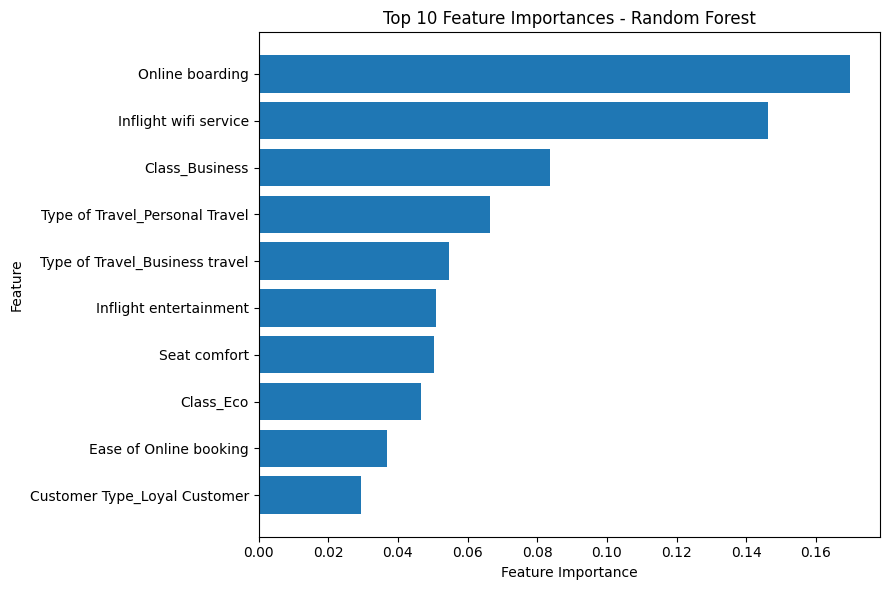

In [22]:
# Calculate and display the 10 most important features used by the tuned Random Forest

feature_names = tuned_model.named_steps["preprocessor"].get_feature_names_out()
importances = tuned_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).round(4))

top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [23]:
# Save the final trained Random Forest pipeline so it can be used by the Streamlit app

from pathlib import Path
import pickle

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

with open(model_dir / "random_forest_model.pkl", "wb") as f:
    pickle.dump(tuned_model, f)

print("Saved: models/random_forest_model.pkl")

Saved: models/random_forest_model.pkl
